## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero - Junio del 2026

---
# Fase 4 — Herramienta de Captura de Dataset
## `MDL_fase4_captura_dataset.ipynb`

### Propósito
Esta notebook es una **herramienta auxiliar independiente**. Su único objetivo es
construir el dataset de rostros que consumirá la notebook principal (`MDL_fase4_reconocimiento_facial.ipynb`).

### Flujo de trabajo
```
  ① Ingresar nombre del sujeto
       ↓
  ② Crear carpeta  /reconocimiento_facial/{nombre_usuario}/
       ↓
  ③ Captura con webcam  →  detección Haar Cascade  →  recorte cuadrado del rostro
       ↓
  ④ Guardar imágenes  →  mosaico de validación
       ↓
  ⑤ Comprimir carpeta  →  {nombre_usuario}.zip
```

> **Importante:** Ejecuta esta notebook **una vez por cada sujeto**. Repite el proceso
> cambiando el nombre de usuario para agregar más personas sin afectar los datos ya capturados.

---
## Paso 1 · Instalación de dependencias

OpenCV es la única dependencia externa requerida. `zipfile` y `pathlib` son parte de la
biblioteca estándar de Python.

In [13]:
# Instalar OpenCV si no está disponible
import importlib, subprocess, sys
if importlib.util.find_spec('cv2') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python'])
print('✅  Dependencias verificadas.')

✅  Dependencias verificadas.


---
## Paso 2 · Importaciones y configuración

| Librería | Uso |
|---|---|
| `cv2` | Captura de video, detección de rostros (Haar Cascade), guardado de imágenes |
| `pathlib.Path` | Manejo de rutas independiente del sistema operativo |
| `zipfile` | Compresión del dataset en un solo archivo portable |
| `time` | Control de frecuencia de captura (evitar duplicados por fotograma) |
| `IPython.display` | Mostrar progreso y mosaico dentro de la notebook |

In [14]:
import cv2
import os
import time
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import clear_output, display

# ── Configuración global ──────────────────────────────────────────────────
DATASET_ROOT = Path('reconocimiento_facial')   # Carpeta raíz del proyecto
IMG_SIZE     = 128    # Resolución de cada imagen guardada (px)
META_FOTOS   = 200    # Número de fotos a capturar por sujeto
ALPHA        = 0.25   # Factor de suavizado EMA para el bounding-box (0.1=suave, 1.0=volátil)

DATASET_ROOT.mkdir(parents=True, exist_ok=True)
print(f'📁  Carpeta raíz: {DATASET_ROOT.resolve()}')
print(f'🎯  Meta por sujeto: {META_FOTOS} fotografías')
print(f'🖼   Resolución de salida: {IMG_SIZE}×{IMG_SIZE} px')

📁  Carpeta raíz: C:\Users\memoo\Documents\git\MDL-2026\Proyecto\fase 4\reconocimiento_facial
🎯  Meta por sujeto: 200 fotografías
🖼   Resolución de salida: 128×128 px


---
## Paso 3 · Ingresar nombre del sujeto

El nombre que ingreses aquí determinará la subcarpeta donde se guardarán las imágenes:
`reconocimiento_facial/{nombre_usuario}/`.

> ⚠️  Usa nombres sin espacios y sin caracteres especiales (p.ej. `guillermo`, `sujeto_2`).
> El nombre se normaliza automáticamente a minúsculas.

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# CELDA INTERACTIVA — Ingresar nombre antes de continuar
# ─────────────────────────────────────────────────────────────────────────
nombre_raw    = input('👤  Nombre del sujeto (sin espacios): ')
nombre_usuario = nombre_raw.strip().lower().replace(' ', '_')

if not nombre_usuario:
    raise ValueError('❌  El nombre no puede estar vacío.')

CARPETA_USUARIO = DATASET_ROOT / nombre_usuario
CARPETA_USUARIO.mkdir(parents=True, exist_ok=True)

# Detectar imágenes ya existentes para continuar desde donde se dejó
imgs_previas = sorted(
    [p for p in CARPETA_USUARIO.iterdir()
     if p.suffix.lower() in ('.jpg','.jpeg','.png')],
    key=lambda p: p.stem
)
siguiente_idx = len(imgs_previas)

print('═' * 55)
print(f'  Sujeto           : {nombre_usuario}')
print(f'  Carpeta destino  : {CARPETA_USUARIO.resolve()}')
print(f'  Imágenes previas : {len(imgs_previas)}')
print(f'  Próxima imagen   : img_{siguiente_idx:04d}.jpg')
print('═' * 55)

═══════════════════════════════════════════════════════
  Sujeto           : jose
  Carpeta destino  : C:\Users\memoo\Documents\git\MDL-2026\Proyecto\fase 4\reconocimiento_facial\jose
  Imágenes previas : 482
  Próxima imagen   : img_0482.jpg
═══════════════════════════════════════════════════════


---
## Paso 4 · Captura de imágenes con webcam

### ¿Cómo funciona la detección?

Se utiliza un **clasificador Haar Cascade** (`haarcascade_frontalface_default.xml`) incluido
en OpenCV. Este detector aplica una cascada de filtros rectangulares sobre la imagen para
identificar patrones propios del rostro humano (ojos, nariz, frente).

Para estabilizar el bounding-box entre fotogramas se aplica un **filtro de media exponencial (EMA)**:
```
  x_suave = α·x_detección + (1-α)·x_anterior
```
Esto elimina el efecto de "vibración" del recuadro sin introducir retraso perceptible.

### Controles
| Tecla | Acción |
|---|---|
| `ESPACIO` | Captura la imagen actual (solo si hay rostro detectado) |
| `A` | Captura automática continua (una foto cada 0.3 s) |
| `Q` / `ESC` | Termina la sesión |

In [16]:
# ─────────────────────────────────────────────────────────────────────────
# CAPTURA CON WEBCAM
# ─────────────────────────────────────────────────────────────────────────
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

contador        = siguiente_idx
nuevas          = 0
ultima_captura  = 0
auto_capture    = False
prev_x = prev_y = prev_w = prev_h = 0

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print('⚠  Cámara no disponible. Si tienes imágenes previas en la carpeta, '
          'puedes saltar al Paso 5.')
else:
    print(f'🎥  Cámara lista.  Meta: {META_FOTOS} fotos nuevas')
    print(f'   ESPACIO = captura manual | A = modo automático | Q = terminar')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_eq = cv2.equalizeHist(gray)
        faces   = face_cascade.detectMultiScale(
            gray_eq, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))

        display_frame = frame.copy()
        rostro_crop   = None

        for (det_x, det_y, det_w, det_h) in faces:
            # ── Suavizado EMA ──────────────────────────────────────────
            if prev_w == 0:
                x, y, w, h = det_x, det_y, det_w, det_h
            else:
                x = int(ALPHA*det_x + (1-ALPHA)*prev_x)
                y = int(ALPHA*det_y + (1-ALPHA)*prev_y)
                w = int(ALPHA*det_w + (1-ALPHA)*prev_w)
                h = int(ALPHA*det_h + (1-ALPHA)*prev_h)
            prev_x, prev_y, prev_w, prev_h = x, y, w, h

            # ── Recorte cuadrado con margen del 20% ───────────────────
            cx, cy  = x + w//2, y + h//2
            lado    = int(max(w, h) * 1.20)
            mitad   = lado // 2
            x1 = max(0, cx - mitad);  y1 = max(0, cy - mitad)
            x2 = min(frame.shape[1], cx + mitad)
            y2 = min(frame.shape[0], cy + mitad)

            cv2.rectangle(display_frame, (x1,y1), (x2,y2), (0,230,100), 2)
            crop = frame[y1:y2, x1:x2]
            if crop.shape[0]>0 and crop.shape[1]>0:
                rostro_crop = cv2.resize(crop, (IMG_SIZE,IMG_SIZE),
                                         interpolation=cv2.INTER_AREA)
            break   # solo primer rostro

        if len(faces)==0:
            prev_w = 0

        # ── HUD ───────────────────────────────────────────────────────
        estado    = '✓ Rostro' if rostro_crop is not None else '— Sin rostro'
        color_hud = (0,230,100) if rostro_crop is not None else (0,80,220)
        pct       = min(100, int(nuevas/max(META_FOTOS,1)*100))
        barra     = '█'*(pct//4) + '░'*(25-pct//4)
        modo_txt  = 'AUTO' if auto_capture else 'MANUAL'

        cv2.putText(display_frame, f'{estado}  [{modo_txt}]',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color_hud, 2)
        cv2.putText(display_frame, f'Sujeto: {nombre_usuario}  |  {nuevas}/{META_FOTOS} fotos',
                    (10,60), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255,255,255), 2)
        cv2.putText(display_frame, f'[{barra}] {pct}%',
                    (10,90), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200,200,200), 1)
        cv2.putText(display_frame, 'ESPACIO=capturar | A=auto | Q=salir',
                    (10, display_frame.shape[0]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180,180,180), 1)

        if rostro_crop is not None:
            mini = cv2.resize(rostro_crop, (80,80))
            display_frame[10:90, display_frame.shape[1]-90:display_frame.shape[1]-10] = mini

        cv2.imshow(f'Captura — {nombre_usuario}', display_frame)
        tecla = cv2.waitKey(1) & 0xFF
        ahora = time.time()

        # ── Toggle modo automático ─────────────────────────────────────
        if tecla == ord('a'):
            auto_capture = not auto_capture
            print(f'  🔄  Modo automático: {"ACTIVADO" if auto_capture else "DESACTIVADO"}')

        # ── Captura ────────────────────────────────────────────────────
        capturar = (
            (tecla == ord(' ') or (auto_capture and (ahora - ultima_captura) > 0.3))
            and rostro_crop is not None
            and (ahora - ultima_captura) > 0.15
        )
        if capturar:
            ruta = CARPETA_USUARIO / f'img_{contador:04d}.jpg'
            cv2.imwrite(str(ruta), rostro_crop)
            contador       += 1
            nuevas         += 1
            ultima_captura  = ahora
            if nuevas % 20 == 0:
                print(f'  📷  {nuevas}/{META_FOTOS} imágenes guardadas')
            if nuevas >= META_FOTOS:
                print(f'  ✅  Meta de {META_FOTOS} fotos alcanzada.')
                break

        if tecla in (ord('q'), 27):
            print(f'  ⏹  Sesión terminada. Fotos nuevas: {nuevas}')
            break

    cap.release()
    cv2.destroyAllWindows()

# ── Resumen final ──────────────────────────────────────────────────────────
total_imgs = list(CARPETA_USUARIO.glob('*.jpg'))
print()
print('═'*55)
print(f'  Sujeto           : {nombre_usuario}')
print(f'  Imágenes totales : {len(total_imgs)}')
print(f'  Fotos nuevas     : {nuevas}')
print(f'  Carpeta          : {CARPETA_USUARIO.resolve()}')
print('═'*55)

🎥  Cámara lista.  Meta: 200 fotos nuevas
   ESPACIO = captura manual | A = modo automático | Q = terminar
  🔄  Modo automático: ACTIVADO
  📷  20/200 imágenes guardadas
  📷  40/200 imágenes guardadas
  📷  60/200 imágenes guardadas
  📷  80/200 imágenes guardadas
  📷  100/200 imágenes guardadas
  📷  120/200 imágenes guardadas
  📷  140/200 imágenes guardadas
  📷  160/200 imágenes guardadas
  📷  180/200 imágenes guardadas
  📷  200/200 imágenes guardadas
  ✅  Meta de 200 fotos alcanzada.

═══════════════════════════════════════════════════════
  Sujeto           : jose
  Imágenes totales : 681
  Fotos nuevas     : 200
  Carpeta          : C:\Users\memoo\Documents\git\MDL-2026\Proyecto\fase 4\reconocimiento_facial\jose
═══════════════════════════════════════════════════════


---
## Paso 5 · Validación visual del dataset

Se muestra un mosaico aleatorio de imágenes capturadas para verificar que:
1. Las imágenes son del tamaño correcto (`IMG_SIZE × IMG_SIZE`).
2. El rostro está correctamente centrado y recortado.
3. No hay imágenes corruptas o sin rostro visible.

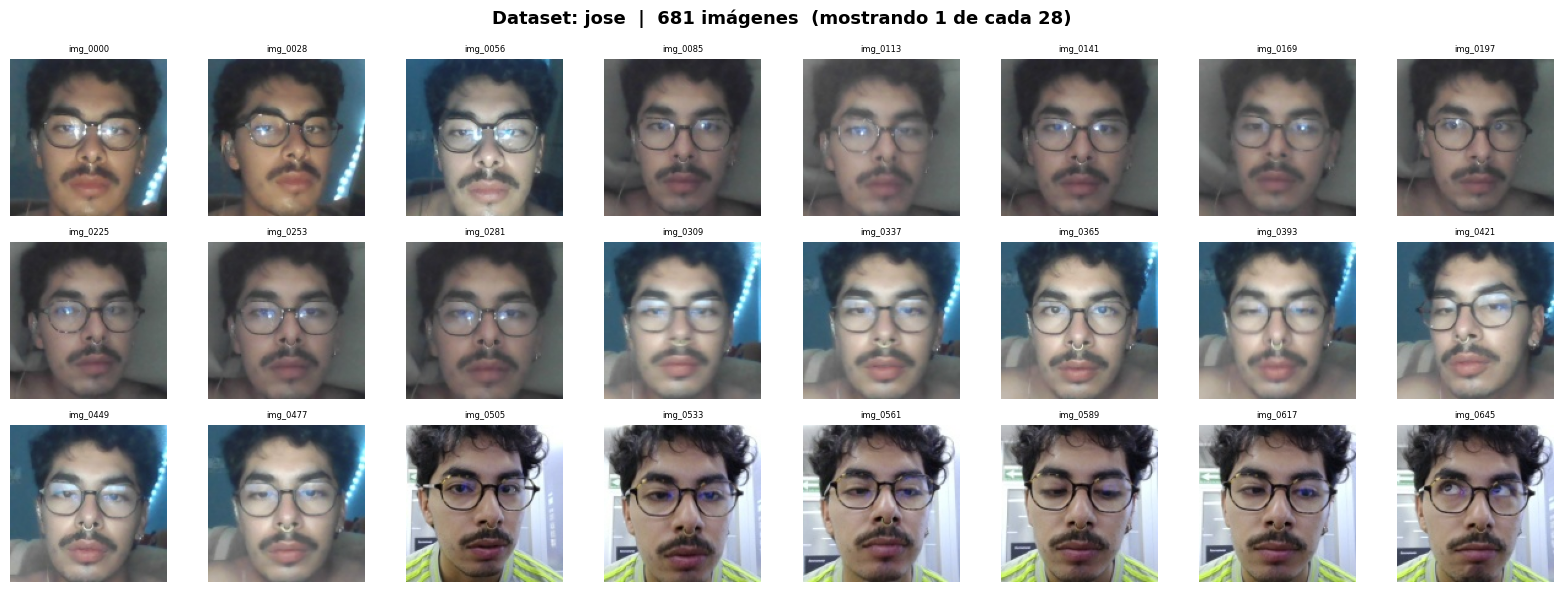

  Mosaico guardado en: reconocimiento_facial\jose\muestra_dataset.png

  Resoluciones detectadas: {(128, 128)}
  ✅  Consistente


In [17]:
# ── Mosaico de validación ─────────────────────────────────────────────────
todas = sorted(CARPETA_USUARIO.glob('*.jpg'))

if len(todas) == 0:
    print('⚠  No se encontraron imágenes en la carpeta. Revisa la captura.')
else:
    # Seleccionar hasta 24 muestras espaciadas uniformemente
    paso    = max(1, len(todas)//24)
    muestra = todas[::paso][:24]

    cols = 8
    rows = -(-len(muestra)//cols)   # ceil division
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows*2))
    fig.suptitle(
        f'Dataset: {nombre_usuario}  |  {len(todas)} imágenes  '
        f'(mostrando 1 de cada {paso})',
        fontsize=13, fontweight='bold'
    )
    for ax, p in zip(axes.flat, muestra):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(p.stem, fontsize=6)
        ax.axis('off')
    for ax in axes.flat[len(muestra):]:
        ax.axis('off')

    plt.tight_layout()
    mosaic_path = CARPETA_USUARIO / 'muestra_dataset.png'
    plt.savefig(str(mosaic_path), dpi=110, bbox_inches='tight')
    plt.show()
    print(f'  Mosaico guardado en: {mosaic_path}')

    # ── Estadísticas básicas ──────────────────────────────────────────
    tamanos = set()
    for p in todas[:50]:   # muestra rápida
        img = cv2.imread(str(p))
        if img is not None:
            tamanos.add(img.shape[:2])

    print(f'\n  Resoluciones detectadas: {tamanos}')
    print(f'  {'✅  Consistente' if len(tamanos)==1 else '⚠  Inconsistente — revisar'}')

---
## Paso 6 · Compresión del dataset

Se genera un archivo `.zip` con toda la carpeta del usuario. Esto facilita:
- Compartir el dataset entre equipos.
- Mover los datos a otro entorno de trabajo.
- Mantener un respaldo antes de entrenar el modelo.

El archivo se guarda en `reconocimiento_facial/{nombre_usuario}.zip`.

In [18]:
# ── Crear ZIP ─────────────────────────────────────────────────────────────
zip_path = DATASET_ROOT / f'{nombre_usuario}.zip'

with zipfile.ZipFile(str(zip_path), 'w', zipfile.ZIP_DEFLATED) as zf:
    for img_path in sorted(CARPETA_USUARIO.glob('*')):
        # arcname: ruta relativa dentro del ZIP
        arcname = img_path.relative_to(DATASET_ROOT)
        zf.write(str(img_path), str(arcname))

zip_size_mb = zip_path.stat().st_size / (1024**2)

print('═'*55)
print(f'  ✅  ZIP creado exitosamente')
print(f'  Archivo  : {zip_path.resolve()}')
print(f'  Tamaño   : {zip_size_mb:.2f} MB')
print(f'  Imágenes : {len(list(CARPETA_USUARIO.glob("*.jpg")))}')
print('═'*55)
print()
print('✔  Dataset listo. Ahora puedes correr MDL_fase4_reconocimiento_facial.ipynb')

═══════════════════════════════════════════════════════
  ✅  ZIP creado exitosamente
  Archivo  : C:\Users\memoo\Documents\git\MDL-2026\Proyecto\fase 4\reconocimiento_facial\jose.zip
  Tamaño   : 5.44 MB
  Imágenes : 681
═══════════════════════════════════════════════════════

✔  Dataset listo. Ahora puedes correr MDL_fase4_reconocimiento_facial.ipynb
